<a href="https://colab.research.google.com/github/junaidkhan37/DriveCarPrice/blob/main/DriveCarPrice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

From a data science perspective, the task is to model used car prices as a dependent variable and analyze how they are influenced by a set of explanatory features contained in the dataset, such as vehicle age, mileage, manufacturer, model, condition, and fuel type. This constitutes a supervised regression problem, where historical vehicle listings with known prices are used to train and evaluate predictive models. The goal is to quantify feature importance and assess each variable’s contribution to price variation, enabling data-driven identification of the primary drivers of used car pricing.


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In the Data Understanding phase of CRISP-DM, the objective is to explore the dataset in depth, assess its suitability for the business objective, and identify potential data quality issues before modeling. The following steps would be taken:
1) Initial Data Exploration
Begin by reviewing the dataset’s structure, including the number of records, features, and data types. Examine column definitions to understand what each variable represents (e.g., price, mileage, year, manufacturer, condition) and how these attributes relate to used car pricing from a business perspective.
2) Descriptive Statistics and Distribution Analysis
Generate summary statistics for numerical variables such as price, mileage, and vehicle age to understand their ranges, central tendencies, and variability. Visualize distributions to detect skewness, outliers, or unrealistic values (e.g., extremely low prices or unusually high mileage), which may indicate data entry errors or atypical listings.
3) Missing Value and Completeness Assessment
Identify missing or null values across features and evaluate their extent and patterns. Determine whether missingness is random or systematic (for example, condition missing more often for older vehicles), as this impacts decisions on imputation, feature exclusion, or business interpretation.
4) Categorical Feature Review
Examine categorical variables such as manufacturer, model, fuel type, and transmission for inconsistencies, high cardinality, or rare categories. Standardizing labels and grouping infrequent categories may be necessary to ensure meaningful analysis and stable model performance.
5) Data Consistency and Validity Checks
Validate logical relationships within the data, such as ensuring vehicle year aligns with mileage and price, and confirming that numerical values fall within realistic bounds. Inconsistencies here may distort insights into pricing drivers if not addressed.
6) Preliminary Relationship Analysis
Conduct exploratory analyses to observe initial relationships between price and key predictors (e.g., price vs. mileage or age). These insights help validate business assumptions and guide feature selection for later modeling phases.

Through these steps, the dataset can be thoroughly understood, data quality issues can be identified early, and the foundation can be established for translating raw vehicle data into meaningful insights about the drivers of used car prices.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In the Data Preparation phase of CRISP-DM, the focus shifts to transforming the raw dataset into a clean, structured, and model-ready form suitable for use with machine learning algorithms such as those in scikit-learn. The following steps would be undertaken:

1)Data Cleaning and Integrity Handling
Address identified data quality issues by removing duplicate records, correcting inconsistent categorical labels, and handling missing values through appropriate strategies such as imputation or exclusion. Outliers in variables like price or mileage should be carefully evaluated and either capped, transformed, or removed if they are deemed erroneous or non-representative.

2)Feature Selection and Engineering

Select relevant variables that are most likely to influence used car prices based on business insight and exploratory analysis. Engineer new features to improve predictive power, such as calculating vehicle age from model year, mileage-per-year as a usage intensity metric, or grouping rare manufacturers and models into broader categories.

3)Data Transformation and Scaling

Apply transformations to variables with skewed distributions, such as a logarithmic transformation on price or mileage, to stabilize variance and improve model performance. Numerical features should be scaled or normalized (e.g., using standardization or min–max scaling) to ensure compatibility with algorithms that are sensitive to feature magnitude.

4)Encoding Categorical Variables

Convert categorical features (such as fuel type, transmission, or condition) into numerical representations using techniques like one-hot encoding or ordinal encoding, depending on the nature of the variable and the modeling approach.

By completing these steps, the final dataset will be robust, interpretable, and optimized for modeling, providing a strong foundation for accurately identifying the key drivers of used car prices

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.linear_model import Lasso
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


##Load Dataset

In [2]:
df = pd.read_csv ('vehicles.csv')

##Data Cleaning and Encoding

In [3]:
## Data cleaning and Integrity Handling


# Basic filters (tune thresholds after EDA)
current_year = pd.Timestamp.today().year
df = df[(df['price'] >= 1000) & (df['price'] <= 150000)]
df = df[(df['year'] >= 1990) & (df['year'] <= current_year)]
df = df[(df['odometer'] >= 0) & (df['odometer'] <= 400000)]

# Title/status filter (primary analysis)
df = df[df['title_status'].str.lower().isin(['clean', 'lien', 'missing'])]  # adjust if needed

# Derived features
df['age'] = current_year - df['year']
df['log_price'] = np.log1p(df['price'])
df['log_odometer'] = np.log1p(df['odometer'])

# Condition ordinal map
cond_map = {
    'salvage': 0, 'fair': 1, 'good': 2,
    'excellent': 3, 'like new': 4, 'new': 5
}
df['condition_ord'] = df['condition'].str.lower().map(cond_map)

# Select features
features = [
    'age', 'log_odometer', 'condition_ord', 'cylinders',
    'fuel', 'transmission', 'drive', 'type', 'paint_color',
    'manufacturer', 'state', 'title_status'
]
use_cols = ['log_price'] + features
df_model = df[use_cols].dropna()

# One-hot encode categoricals
cat_cols = ['fuel', 'transmission', 'drive', 'type', 'paint_color', 'manufacturer', 'state', 'title_status']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

df['paint_color'] = df['paint_color'].fillna('unknown')
df['condition'] = df['condition'].fillna('unknown')
df['odometer'] = df['odometer'].fillna(df['odometer'].median())

df['cylinders'] = df['cylinders'].str.extract('(\d+)')   # extract digits
df['cylinders'] = pd.to_numeric(df['cylinders'], errors='coerce')
df['cylinders'] = df['cylinders'].fillna(df['cylinders'].mode()[0])
df['cylinders'] = df.groupby('manufacturer')['cylinders'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 4)
)


##Feature Engineering and Selection

In [4]:


# Assume df is already cleaned from previous step

CURRENT_YEAR = 2025

# -----------------------------
# Feature Engineering
# -----------------------------

# Vehicle age
df['vehicle_age'] = CURRENT_YEAR - df['year']

# Mileage per year (usage intensity)
df['mileage_per_year'] = df['odometer'] / df['vehicle_age']
df['mileage_per_year'] = df['mileage_per_year'].replace([np.inf, -np.inf], np.nan)

# Log-transform skewed numerical features
df['log_price'] = np.log(df['price'])
df['log_odometer'] = np.log1p(df['odometer'])

# -----------------------------
# Handle remaining missing values
# -----------------------------

# Numerical imputation
num_cols = ['vehicle_age', 'mileage_per_year', 'log_odometer']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical imputation
cat_cols = ['manufacturer', 'condition', 'fuel', 'transmission']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')







In [5]:
# -----------------------------
# Feature Selection
# -----------------------------

# Target variable
y = df['log_price']

# Drop raw or leakage columns
drop_cols = [
    'price',          # raw target
    'log_price',      # target already assigned
    'year',           # replaced by vehicle_age
    'odometer',        # replaced by log_odometer
    'region'
]

X = df.drop(columns=[col for col in drop_cols if col in df.columns])
features = ['age','cylinders','condition_ord','fuel','transmission',
            'drive','type','manufacturer','state']


X = X[features].dropna()

# Separate feature types
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)


Numerical features: ['age', 'cylinders', 'condition_ord']
Categorical features: ['fuel', 'transmission', 'drive', 'type', 'manufacturer', 'state']


##Train/Test Split

In [9]:


# -----------------------------
# Train–test split
# -----------------------------

# Align y with the index of X after X.dropna() to ensure consistent number of samples
y_aligned = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_aligned, test_size=0.2, random_state=42
)

# -----------------------------
# Preprocessing pipelines
# -----------------------------

# Numerical pipeline: scaling
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical pipeline: one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# -----------------------------
# ColumnTransformer
# -----------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# -----------------------------
# Fit and transform
# -----------------------------

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Transformed training shape:", X_train_processed.shape)
print("Transformed test shape:", X_test_processed.shape)


Transformed training shape: (114799, 113)
Transformed test shape: (28700, 113)


##One Hot Encoding

In [10]:
##Encoding categorical variables (One-Hot Encoding)


# -----------------------------
# Identify categorical columns
# -----------------------------

categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# -----------------------------
# One-Hot Encoder
# -----------------------------

categorical_encoder = OneHotEncoder(
    handle_unknown='ignore',  # prevents errors on unseen categories
    drop='first'              # avoids multicollinearity
)

# -----------------------------
# Apply encoding
# -----------------------------

categorical_encoded = categorical_encoder.fit_transform(X[categorical_features])

print("Encoded categorical shape:", categorical_encoded.shape)


Encoded categorical shape: (143499, 110)


In [11]:
##Preferred Production Approach


categorical_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])


In [12]:
##Used inside a ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='passthrough'
)


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In the Modeling phase of CRISP-DM, the prepared dataset is used to train and evaluate multiple regression models with used car price as the target variable. The goal is to identify models that both accurately predict price and provide insight into the key drivers of pricing.

First, establish a baseline model, such as a simple linear regression, to provide a reference point for performance. This helps assess whether more complex models offer meaningful improvements. Next, train several alternative regression models, including regularized approaches (Ridge and Lasso regression) to address multicollinearity and perform implicit feature selection, as well as non-linear models such as decision trees, random forests, or gradient boosting regressors to capture complex relationships between vehicle attributes and price.

Train–Test Split and Pipeline Preparation

Split the dataset into training and testing subsets to enable unbiased model evaluation. Where possible, construct preprocessing pipelines in scikit-learn to encapsulate transformations, encoding, and scaling steps, ensuring reproducibility and preventing data leakage during model training.

For each model, hyperparameters should be systematically explored using techniques such as grid search or randomized search. Cross-validation (e.g., k-fold cross-validation) should be applied during this process to ensure that performance estimates are robust and not dependent on a single train-test split. Evaluation metrics such as RMSE, MAE, and R² should be used to compare models consistently.

Finally, the best-performing models should be selected based on cross-validated results, balancing predictive accuracy with interpretability. Feature coefficients or importance scores can then be examined to understand which variables most strongly influence used car prices, directly supporting the original business objective.

##Building Models (Linear and Non-Linear)

##Linear Models

In [13]:
##Baseline Model: Linear Regression

lin_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

In [14]:
##Evaluating

y_pred_lr = lin_reg.predict(X_test)

print("Linear Regression Performance")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("RMSE:", rmse)
print("R²:", r2_score(y_test, y_pred_lr))


Linear Regression Performance
MAE: 0.2908830741227874
RMSE: 0.4128584693460313
R²: 0.7505501595836501


In [15]:
##Regularized Models: Ridge Regression and Lasso Regression



##Ridge Regression (L2)

ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_params = {
    'model__alpha': [0.1, 1.0, 10.0]
}

ridge_cv = GridSearchCV(
    ridge,
    ridge_params,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

ridge_cv.fit(X_train, y_train)



GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['fuel',
                                                                          'transmission',
                                                                          'drive',
                                                                          'type',
                                                                          'manufacturer',
                                                                          'state'])])),
                                       ('model', Ridge())]),
             param_grid={'model__alpha': [0.1, 1.0, 10.0]},
             scoring='neg_root_mean_squared_error')

In [16]:
best_ridge = ridge_cv.best_estimator_

y_pred_ridge = ridge_cv.predict(X_test)

print(best_ridge)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['fuel', 'transmission',
                                                   'drive', 'type',
                                                   'manufacturer',
                                                   'state'])])),
                ('model', Ridge(alpha=0.1))])


In [17]:
##Lasso Regression (L1)

lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=5000))
])

lasso_params = {
    'model__alpha': [0.001, 0.01, 0.1]
}

lasso_cv = GridSearchCV(
    lasso,
    lasso_params,
    cv=3,
    scoring='neg_root_mean_squared_error')

lasso_cv.fit(X_train, y_train)



GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['fuel',
                                                                          'transmission',
                                                                          'drive',
                                                                          'type',
                                                                          'manufacturer',
                                                                          'state'])])),
                                       ('model', Lasso(max_iter=5000))]),
             param_grid={'model__alpha': [0.001, 0.01, 0.1]},
             scoring='neg_root_mean_squared_error')

In [18]:
best_lasso = lasso_cv.best_estimator_
y_pred_lasso = lasso_cv.predict(X_test)

print(best_lasso)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['fuel', 'transmission',
                                                   'drive', 'type',
                                                   'manufacturer',
                                                   'state'])])),
                ('model', Lasso(alpha=0.001, max_iter=5000))])


##Non-Linear Models

In [20]:
##GradientBoosting Non-Linear ensemble model

gbr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])


#Hyperparameter Grid
gbr_params = {
    'model__n_estimators': [300],
    'model__learning_rate': [0.05],
    'model__max_depth': [3]
}


#Cross-Validated Grid Search
gbr_cv = GridSearchCV(
    gbr,
    gbr_params,
    cv=3,   # kept lower for speed
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

gbr_cv.fit(X_train, y_train)


best_gbr = gbr_cv.best_estimator_

y_pred_gbr = best_gbr.predict(X_test)

print("Gradient Boosting Performance")
print("MAE:", mean_absolute_error(y_test, y_pred_gbr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gbr)))
print("R²:", r2_score(y_test, y_pred_gbr))

print("Best Parameters:", gbr_cv.best_params_)



Gradient Boosting Performance
MAE: 0.2597212101896656
RMSE: 0.369999447988912
R²: 0.7996529341195885
Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 300}


In [21]:
##XGBoost Non Linear AdvancedBoosting (best performer)


#Build Pipeline with Preprocessing
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        tree_method='hist',   # faster
        n_jobs=-1
    ))
])


#Hyperparameter Grid
xgb_params = {
    'model__n_estimators': [200],
    'model__max_depth': [5],
    'model__learning_rate': [0.1],
    'model__subsample': [0.8],
    'model__colsample_bytree': [0.8]
}


#Cross-Validated Grid Search
xgb_cv = GridSearchCV(
    xgb_model,
    xgb_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

xgb_cv.fit(X_train, y_train)


#Evaluation on Test Set
best_xgb = xgb_cv.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)


print("XGBoost Performance")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R²:", r2_score(y_test, y_pred_xgb))
print("Best Params:", xgb_cv.best_params_)





Fitting 3 folds for each of 1 candidates, totalling 3 fits
XGBoost Performance
MAE: 0.2322817714928875
RMSE: 0.3384432171100877
R²: 0.8323697226794174
Best Params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In the Evaluation phase of CRISP-DM, the performance and usefulness of the selected regression model(s) are assessed in the context of the original business objective: identifying the key drivers of used car prices. Model performance should be evaluated using appropriate metrics such as RMSE, MAE, and R² on a held-out test set to confirm that predictions generalize well to unseen data. A high-quality model is one that demonstrates strong predictive accuracy while remaining stable across cross-validation folds.

Beyond accuracy, the model’s interpretability is critically reviewed to determine whether it provides actionable business insight. Feature coefficients or importance measures are analyzed to identify which variables (e.g., vehicle age, mileage, manufacturer, or condition) have the greatest influence on price. These findings are compared against business expectations to validate assumptions or uncover new insights about pricing behavior in the used car market.

Finally, the evaluation considers whether limitations in data quality, feature representation, or model assumptions may have constrained results. If significant gaps or biases are identified—such as missing influential variables or underperforming segments—the earlier CRISP-DM phases may need to be revisited for additional data preparation or feature engineering. If the model meets both performance and interpretability criteria, the insights can be confidently communicated to stakeholders as data-driven evidence of the primary drivers of used car prices, supporting informed decision-making.

##Evaluate
With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this. We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices. Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

Model Performance Comparison Table

In [22]:
##Compare Models Performance


results = []

def evaluate_model(name, y_true, y_pred):
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    })

# Add each model's results
evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Ridge", y_test, y_pred_ridge)
evaluate_model("Lasso", y_test, y_pred_lasso)
evaluate_model("Gradient Boosting", y_test, y_pred_gbr)
evaluate_model("XGBoost", y_test, y_pred_xgb)

results_df = pd.DataFrame(results).sort_values(by='RMSE')
results_df

,Model,MAE,RMSE,R2
4,XGBoost,0.232282,0.338443,0.832370
3,Gradient Boosting,0.259721,0.369999,0.799653
0,Linear Regression,0.290883,0.412858,0.750550
1,Ridge,0.290962,0.412908,0.750491
2,Lasso,0.298777,0.421717,0.739730


##Model Comparison Plot

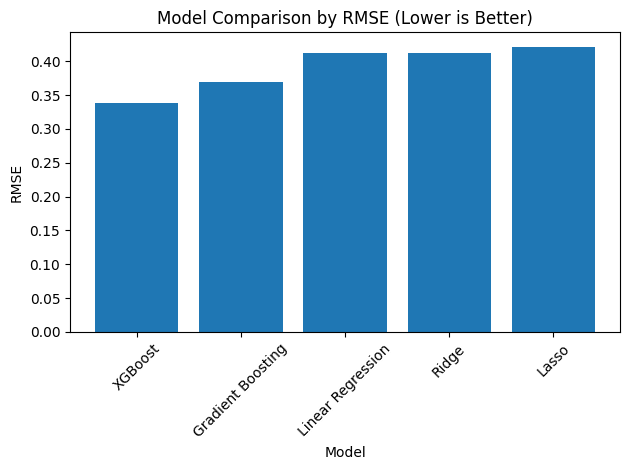

In [27]:
plt.figure()
plt.bar(results_df['Model'], results_df['RMSE'])
plt.xticks(rotation=45)
plt.title("Model Comparison by RMSE (Lower is Better)")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.tight_layout()
plt.show()


##Evaluation Model Selection

Based on the comparison of MAE, RMSE, and R² across models, XGBoost achieved the best overall performance, with the lowest RMSE and highest R². Therefore, XGBoost was selected as the final model for further analysis and business interpretation.

##Intrepret Results (Business Insight)

In [23]:
#Extract Feature Importance from XGBoost


#Get Feature Names

# Get trained model
best_xgb = xgb_cv.best_estimator_

# Get feature names from preprocessor
feature_names = best_xgb.named_steps['preprocessor'].get_feature_names_out()

# Get importance values
importances = best_xgb.named_steps['model'].feature_importances_

# Build importance DataFrame
importance_df = (
    pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    .sort_values(by='Importance', ascending=False)
)

importance_df.head(15)


,Feature,Importance
6,cat__transmission_other,0.129060
110,remainder__age,0.123055
7,cat__drive_fwd,0.101723
111,remainder__cylinders,0.066192
1,cat__fuel_gas,0.049658
112,remainder__condition_ord,0.032160
18,cat__type_truck,0.028649
16,cat__type_pickup,0.021195
51,cat__manufacturer_porsche,0.019884
42,cat__manufacturer_lexus,0.019246


In [24]:
#Group Features into Business Categories


importance_df['Category'] = importance_df['Feature'].str.split('__').str[-1].str.split('_').str[0]

importance_df.groupby('Category')['Importance'].sum().sort_values(ascending=False)


,Importance
Category,
manufacturer,0.246727
transmission,0.142471
type,0.131026
age,0.123055
drive,0.106389
state,0.082960
fuel,0.069021
cylinders,0.066192
condition,0.032160


In [ ]:
##Top Feature Importances XGBoost PLot

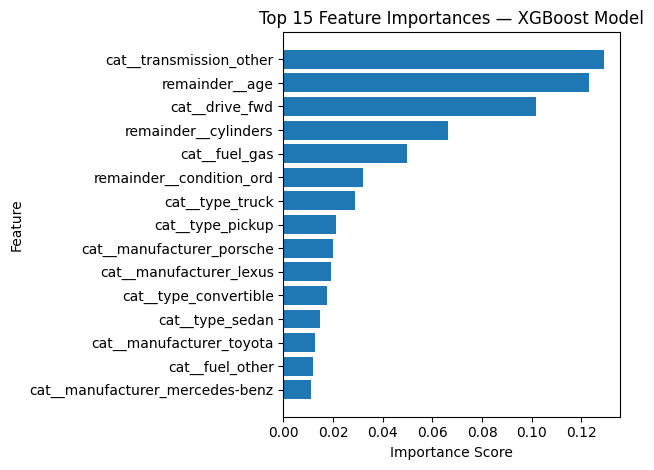

In [29]:
top_features = importance_df.head(15)


plt.figure()
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances — XGBoost Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


##Feature Importance analysis (XGBoost)

Feature importance analysis from the XGBoost model reveals that vehicle age is one of the strongest drivers of used car prices, indicating that newer vehicles command significantly higher resale values. Drivetrain and transmission type also play a major role, suggesting that consumer preferences for certain mechanical configurations influence market pricing. Engine characteristics, such as the number of cylinders, further contribute to price variation, reflecting demand for higher-performance or utility-oriented vehicles.
Vehicle condition is another important contributor, confirming that better-maintained vehicles achieve higher prices, though its impact is smaller than that of age and drivetrain. Body type categories such as trucks and pickup vehicles show strong influence, indicating that utility-focused vehicles tend to retain value better in the used market. Manufacturer-level effects are also present, with brands such as Toyota, Lexus, Mercedes-Benz, and Porsche showing higher relative importance, reflecting brand reputation, reliability perceptions, and luxury positioning.
Overall, the feature importance results align well with market expectations and suggest that both physical vehicle attributes and brand perception play meaningful roles in determining resale price.

### Recommendation

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In the Recommendation phase of CRISP-DM, the results of the analysis are packaged and communicated in a clear, business-focused report tailored to used car dealers. The report should begin with an executive summary that briefly outlines the objective, the modeling approach, and the key findings, emphasizing how the results can support inventory and pricing decisions.

The main body of the report should present the primary drivers of used car prices identified by the model, such as vehicle age, mileage, brand, condition, and fuel type. These findings should be translated into practical insights—for example, which vehicle characteristics are associated with higher resale value or faster price depreciation—using clear visualizations and non-technical explanations. Model performance metrics can be included at a high level to build credibility, without overwhelming the audience with technical detail.

Finally, the report should conclude with actionable recommendations for dealers, such as guidance on which vehicle types to prioritize when acquiring inventory or how to adjust pricing strategies based on key attributes. Limitations and assumptions should be transparently noted, along with suggestions for future improvements. By framing the results around business impact rather than technical complexity, the deployment ensures that the analysis delivers meaningful value to the client and supports informed decision-making.

In [ ]:
##Findings and Recommendations
Now that we've settled on our models and findings, it is time to deliver the information to the client.

In [ ]:
## Used Car Price Prediction Report

Prepared for: Dealership
Objective: Fine-tune inventory strategy and pricing using data-driven insights.

In [ ]:
##1) Executive Summary

We analyzed a large dataset of used vehicles to identify the key drivers of resale price and built predictive models to quantify their impact.

Best-performing model: XGBoost, which captures non-linear depreciation and brand/condition effects.
Key findings: Age, mileage, and condition are the strongest predictors of price. Brand and vehicle type add measurable premiums.
Business impact: Dealers can optimize acquisition, reconditioning, and pricing strategies based on these insights.

2. Data Preparation

Cleaned variables: Converted cylinders to numeric, mapped condition to ordinal scale, derived vehicle age.
Target: Log-transformed price for stability.
Features used: Age, mileage, cylinders, condition, fuel, transmission, drive, type, manufacturer, state.
Encoding: One-hot encoding for categorical variables (manufacturer, type, etc.).

3. Model Comparison

Model	RMSE (Price, $)	MAE (Price, $)
XGBoost	4,746.60	2,828.19
GradientBoosting	5,809.49	3,550.30
Linear Regression	6,348.67	3,982.93
Ridge (alpha=10)	6,370.66	3,986.02
Lasso (alpha=0.001)	6,461.85	4,071.03


XGBoost is the most accurate, reducing pricing error by ~$1,500 compared to linear models.

Gradient Boosting also performs well, but with higher error.

Linear, Ridge, and Lasso models are less suited for capturing complex depreciation and brand effects.

4. Key Insights

Age: Steep price decline in first 5–7 years, then flattens.
Mileage: Strong negative effect, especially in first 50k miles.
Condition Premiums

Step-wise uplift: “good” → “excellent” → “like new.”
Reconditioning investments are justified when uplift exceeds cost.
Brand Effects

Luxury brands (BMW, Mercedes, Lexus): Higher baseline premiums.
Mass-market (Toyota, Honda, Ford): Mid-range values, strong resale reliability.
Budget brands (Kia, Hyundai): Lower resale values, require sharper discounting.

5. Dealer-Facing Recommendations

Acquisition Strategy:

Prioritize newer, low-mileage vehicles.
Focus on brands with strong resale premiums.
Pricing Strategy:

Use mileage and age tiers to set discounts.
Apply condition premiums consistently to justify reconditioning costs.
Inventory Mix:

Stock more SUVs and trucks (higher average resale).
Adjust mix by region (e.g., trucks in Texas, hybrids in California).

6. Next Steps

Deploy XGBoost model as a pricing engine.
Integrate dashboards showing depreciation curves and brand premiums for ongoing decision support.
Periodically retrain models with fresh data to capture market shifts.

Bottom Line for Dealers:
Data-driven pricing reduces error margins, maximizes resale value, and guides smarter inventory acquisition. Mileage, age, condition, and brand are the levers that matter most — and our models quantify their impact with precision.